**RETAIL BUSINESS ANALYTICS DATASET - FULL PIPLINE**

**BS Data Analyst Capstone Project**

 **Tools: Python (pandas, statsmodels, sklearn) → later SQL/Power BI**

In [1]:
# 1. Importing Libraries
# These are the necessary Libraries imports for data analysis, visualization, and modeling.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Loading the dataset
df = pd.read_csv(r'C:\Users\ayan\Desktop\Business Retail Project\Business_Analytics_Dataset.csv')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Order_ID,Customer_ID,Order_Date,Region,Product_Category,Customer_Segment,Quantity,Unit_Price,Discount_Rate,Revenue,Cost,Profit,Payment_Method
0,1,CUST3818,8/18/2024,North,Clothing,Corporate,5,300.68,0.27,1097.48,768.29,329.19,Credit Card
1,2,CUST9689,6/19/2024,South,Beauty,Home Office,9,32.89,0.02,290.09,179.33,110.76,Debit Card
2,3,CUST9147,11/21/2024,West,Sports,Corporate,5,345.61,0.25,1296.04,1022.60,273.44,Credit Card
3,4,CUST7938,7/19/2024,North,Clothing,Consumer,1,444.50,0.06,417.83,280.99,136.84,UPI
4,5,CUST5127,10/28/2024,South,Home & Kitchen,Consumer,5,65.13,0.21,257.26,151.90,105.36,Credit Card


In [9]:
# ----------- 2. DATA CLEANING ------------

print("=== DATA CLEANING STARTED ===")

# 2.1 Basic Info
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# 2.2 Duplicate Check
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed!")

# 2.3 Convert Order_Date to datetime
if 'Order_Date' in df.columns:
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
    print("Order_Date converted to datetime")

# 2.4 Check & Fix Negative/Zero Values (logical errors)
numeric_cols = ['Quantity', 'Unit_Price', 'Revenue', 'Cost', 'Profit']
for col in numeric_cols:
    if col in df.columns:
        negative = (df[col] < 0).sum()
        print(f"{col}: {negative} negative values")
        if negative > 0:
            df = df[df[col] >= 0]   # Remove illogical rows

# 2.5 Outlier Detection & Handling (IQR Method)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['Revenue', 'Profit', 'Quantity']:
    if col in df.columns:
        original = len(df)
        df = remove_outliers_iqr(df, col)
        print(f"Outliers removed from {col}: {original - len(df)} rows")

# 2.6 Final Cleaned Info
print("\n=== CLEANING COMPLETE ===")
print(f"Final Shape: {df.shape}")
print("Missing values after cleaning:", df.isnull().sum())

# Save cleaned version for SQL/Power BI
df.to_csv('retail_cleaned_for_capstone.csv', index=False)
print("✅ Cleaned file saved as 'retail_cleaned_for_capstone.csv'")

=== DATA CLEANING STARTED ===

Data Types:
 Order_ID              int64
Customer_ID             str
Order_Date              str
Region                  str
Product_Category        str
Customer_Segment        str
Quantity              int64
Unit_Price          float64
Discount_Rate       float64
Revenue             float64
Cost                float64
Profit              float64
Payment_Method          str
dtype: object

Missing Values:
 Order_ID            0
Customer_ID         0
Order_Date          0
Region              0
Product_Category    0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Rate       0
Revenue             0
Cost                0
Profit              0
Payment_Method      0
dtype: int64

Duplicate Rows: 0
Order_Date converted to datetime
Quantity: 0 negative values
Unit_Price: 0 negative values
Revenue: 0 negative values
Cost: 0 negative values
Profit: 0 negative values
Outliers removed from Revenue: 153 rows
Outliers removed from Profit: 243 


=== STATISTICAL ANALYSIS ===
          Quantity   Unit_Price      Revenue         Cost       Profit
count  9604.000000  9604.000000  9604.000000  9604.000000  9604.000000
mean      5.361933   247.866876  1095.707556   719.213356   376.494200
std       2.813993   138.172985   858.948996   588.870578   304.952582
min       1.000000    10.000000     8.590000     5.740000     1.970000
25%       3.000000   127.877500   379.217500   244.492500   126.475000
50%       5.000000   245.360000   876.715000   564.275000   293.755000
75%       8.000000   363.990000  1644.917500  1056.510000   559.502500
max      10.000000   499.940000  3833.470000  3023.420000  1276.830000


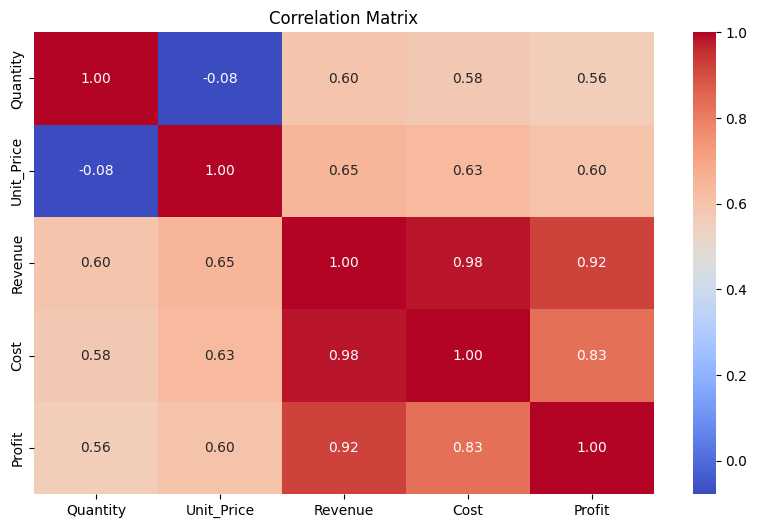


Average Profit by Category:
Product_Category
Beauty            382.47
Clothing          368.42
Electronics       388.89
Home & Kitchen    367.54
Sports            375.23
Name: Profit, dtype: float64

Average Profit by Region:
Region
East     373.88
North    374.30
South    379.43
West     378.46
Name: Profit, dtype: float64

T-test Profit (Premium vs Standard): t-stat = nan, p-value = nan
→ No significant difference


In [11]:
# ----------- 3. STATISTICS CALCULATIONS -----------

print("\n=== STATISTICAL ANALYSIS ===")

# 3.1 Descriptive Statistics
print(df[['Quantity', 'Unit_Price', 'Revenue', 'Cost', 'Profit']].describe())

# 3.2 Correlation Matrix (Heatmap)
plt.figure(figsize=(10, 6))
corr = df[['Quantity', 'Unit_Price', 'Revenue', 'Cost', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# 3.3 Group Statistics (by Category & Region)
print("\nAverage Profit by Category:")
print(df.groupby('Product_Category')['Profit'].mean().round(2))

print("\nAverage Profit by Region:")
print(df.groupby('Region')['Profit'].mean().round(2))

# 3.4 Hypothesis Testing - T-test for Profit between "Premium" and "Standard" Customer Segments
if 'Customer_Segment' in df.columns:
    premium = df[df['Customer_Segment'] == 'Premium']['Profit']
    standard = df[df['Customer_Segment'] == 'Standard']['Profit']
    t_stat, p_value = stats.ttest_ind(premium, standard, nan_policy='omit')
    print(f"\nT-test Profit (Premium vs Standard): t-stat = {t_stat:.4f}, p-value = {p_value:.4f}")
    print("→ Significant difference!" if p_value < 0.05 else "→ No significant difference")

In [17]:
# ----------- 4. FEATURE ENGINEERING -----------

# Create useful columns
df['Profit_Margin'] = (df['Profit'] / df['Revenue'] * 100).round(2)
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Day_of_Week'] = df['Order_Date'].dt.day_name()

# One-hot encoding for categorical variables (needed for regression)
categorical_cols = ['Product_Category', 'Region', 'Customer_Segment', 'Payment_Method']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("✅ Feature Engineering Done!")
print("New columns added: Profit_Margin, Year, Month, Day_of_Week + dummies")

✅ Feature Engineering Done!
New columns added: Profit_Margin, Year, Month, Day_of_Week + dummies


In [19]:
# ----------- 5. REGRESSION MODEL (Predict Profit) -----------

print("\n=== MULTIPLE LINEAR REGRESSION MODEL ===")

# Define features (X) and target (y)
features = ['Quantity', 'Unit_Price'] + [col for col in df_encoded.columns if col.startswith(('Category_', 'Region_', 'Customer_Segment_', 'Payment_Method_'))]
X = df_encoded[features]
y = df_encoded['Profit']

# Add constant for statsmodels
X_const = sm.add_constant(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------- 5.2 Scikit-learn (For Predictions & Metrics) -----------
model_sk = LinearRegression()
model_sk.fit(X_train, y_train)

# Predictions
y_pred = model_sk.predict(X_test)

# Evaluation Metrics
print("\nModel Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Feature Importance
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model_sk.coef_
}).sort_values('Coefficient', ascending=False)
print("\nTop Features impacting Profit:\n", coefficients.head(10))


=== MULTIPLE LINEAR REGRESSION MODEL ===

Model Performance:
R² Score: 0.7440
Mean Absolute Error: 122.11
Root Mean Squared Error: 155.35

Top Features impacting Profit:
                          Feature  Coefficient
0                       Quantity    66.000770
6   Customer_Segment_Home Office     6.126671
2                   Region_North     6.121638
10            Payment_Method_UPI     5.485799
3                   Region_South     3.789635
4                    Region_West     2.316065
1                     Unit_Price     1.432984
5     Customer_Segment_Corporate    -0.094700
7     Payment_Method_Credit Card    -2.492818
9     Payment_Method_Net Banking    -5.440157


In [20]:
# ----------- 6. SAVE MODEL & FINAL FILES -----------
import joblib
joblib.dump(model_sk, 'profit_regression_model.pkl')
print("\n✅ Model saved as 'profit_regression_model.pkl'")
print("✅ Everything ready for your capstone report + Power BI dashboard!")


✅ Model saved as 'profit_regression_model.pkl'
✅ Everything ready for your capstone report + Power BI dashboard!


In [25]:
# Now we are ready to move in postgresql for further analysis and dashboard creation.
import psycopg2
from psycopg2 import sql

DB_USER     = "postgres"
DB_PASSWORD = "ayaan123"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "Retail_db"

conn = psycopg2.connect(
    dbname=DB_NAME,
    user=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT
)

# Create cursor
cur = conn.cursor()


# Export using pandas + copy_from (very fast for large data)
from io import StringIO

output = StringIO()
df.to_csv(output, sep='\t', header=False, index=False)
output.seek(0)

cur.copy_from(output, 'sales', null="")
conn.commit()

cur.close()
conn.close()

print("✅ Data exported using psycopg2 copy_from – very fast!")


UndefinedTable: relation "sales" does not exist
